# Dataset Description

This dataset contains historical sales transactions for a fictional Superstore operating in the United States, with information on orders, products, customers, and shipping. It includes around 9–10k rows and roughly 20 columns covering order details (order ID, dates, ship mode), geography (state, city, region), product hierarchy (category, sub‑category), and performance metrics such as sales, quantity, discount, and profit. The data is commonly used for learning analytics and BI topics like sales performance, profitability, customer segmentation, and forecasting.`

## # Data Dictionary – Superstore Dataset

This dataset contains retail transaction records for a superstore business. It includes order details, customer information, regional attributes, product hierarchy, and key performance measures like sales, quantity, discount, and profit.

## Column descriptions

### Order and row identifiers
- **Row ID**: Unique numeric identifier for each row.
- **Order ID**: Unique identifier for each order.
- **Order Date**: Date when the order was placed.
- **Ship Date**: Date when the order was shipped.
- **Ship Mode**: Shipping method used for delivery.

### Customer information
- **Customer ID**: Unique identifier for each customer.
- **Customer Name**: Name of the customer.
- **Segment**: Type of customer segment such as Consumer, Corporate, or Home Office.

### Geographic information
- **Country**: Country where the customer/order belongs.
- **City**: City of the order destination.
- **State**: State of the order destination.
- **Postal Code**: ZIP/postal code of the destination.
- **Region**: Broad region such as East, West, Central, or South.

### Product information
- **Product ID**: Unique identifier for each product.
- **Category**: Main product category.
- **Sub-Category**: More specific product grouping within a category.
- **Product Name**: Full name of the product.

### Business metrics
- **Sales**: Revenue generated from the transaction.
- **Quantity**: Number of units sold.
- **Discount**: Discount applied to the transaction.
- **Profit**: Profit earned from the transaction.



In [12]:
import pandas as pd
import numpy as np
# reading the data set

df_raw = pd.read_csv("/content/drive/MyDrive/Github/Superstore Project/archive/Sample - Superstore.csv", encoding='latin1')
df_raw.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [13]:
df_raw.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [14]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [15]:
df = df_raw.copy()

def to_snake(name: str) -> str:
    return (
        name.strip()
            .lower()
            .replace(" ", "_")
            .replace("-", "_")
    )

df.columns = [to_snake(c) for c in df.columns]
print(df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')


In [16]:
# 1) Convert order_date and ship_date from string to datetime
date_cols = ["order_date", "ship_date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%m/%d/%Y", errors="coerce")

# 2) Optionally convert postal_code to string (it is an identifier, not a number)
df["postal_code"] = df["postal_code"].astype(str)

print(df[date_cols + ["postal_code"]].dtypes)

order_date     datetime64[ns]
ship_date      datetime64[ns]
postal_code            object
dtype: object


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   object        
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null   object        
 15  sub_category   9994 n

In [18]:
# Row ID is just a running row number, not needed for analysis
df = df.drop(columns=["row_id"])

print(df.columns)

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id',
       'customer_name', 'segment', 'country', 'city', 'state', 'postal_code',
       'region', 'product_id', 'category', 'sub_category', 'product_name',
       'sales', 'quantity', 'discount', 'profit'],
      dtype='object')


# EDA Exploratory Data Analysis


### EDA – Visual Exploration

In this section, we use visualizations to better understand the Superstore dataset.

We will answer the following questions visually:

1. How many units were sold in each category?
2. Which categories generate the highest sales?
3. Which products are the top-selling products by units sold?
4. What are the top-selling products within each category?
5. How do monthly sales change over time?
6. What is the relationship between sales, profit, discount, and quantity?

/tmp/ipykernel_3039/3754428073.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=units_per_category, x="category", y="total_units_sold", palette="Blues_d")


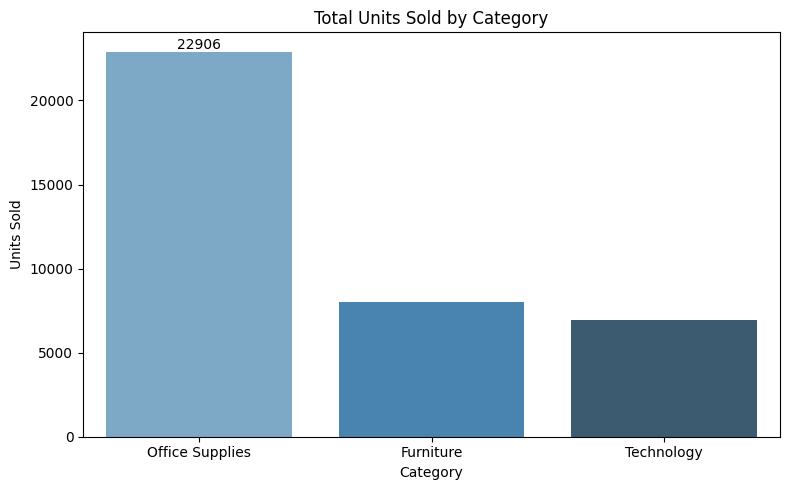

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Unit Sold By Category
units_per_category = (
    df.groupby("category")["quantity"]
      .sum()
      .reset_index(name="total_units_sold")
      .sort_values("total_units_sold", ascending=False)
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=units_per_category, x="category", y="total_units_sold", hue="category", palette="Blues_d", legend=False)
ax.bar_label(ax.containers[0], fmt="%.0f")
plt.title("Total Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3039/3495246084.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=sales_per_category, x="category", y="total_sales", palette="Greens_d")


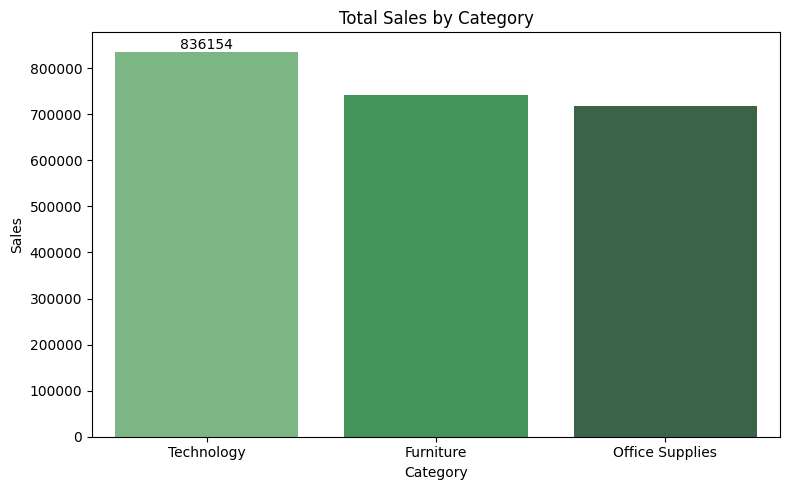

In [20]:
#Sales Per Category
sales_per_category = (
    df.groupby("category")["sales"]
      .sum()
      .reset_index(name="total_sales")
      .sort_values("total_sales", ascending=False)
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=sales_per_category, x="category", y="total_sales", palette="Greens_d")
ax.bar_label(ax.containers[0], fmt="%.0f")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3039/1231522302.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_products_units, y="product_name", x="total_units_sold", palette="Purples_d")


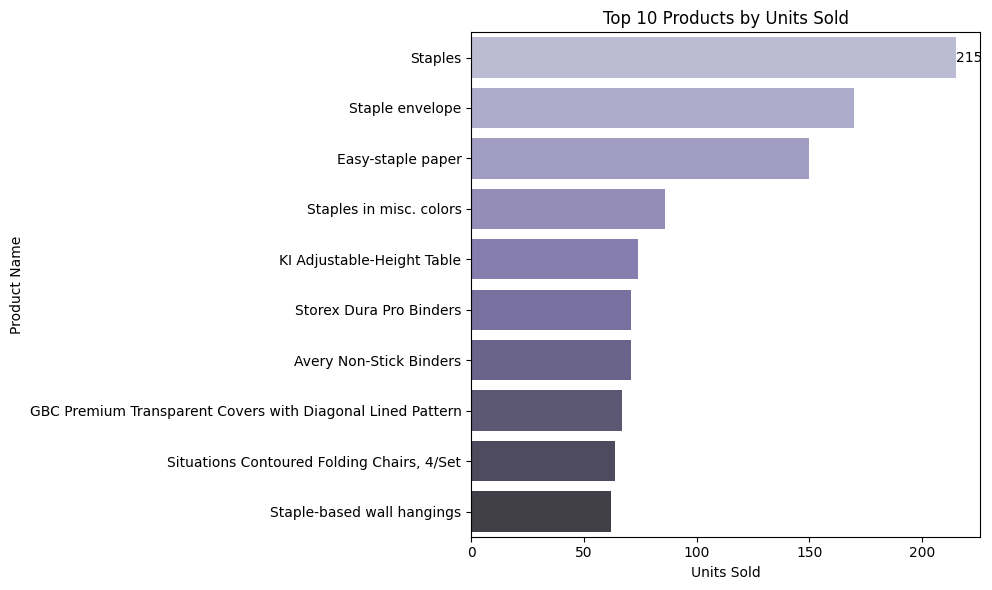

In [21]:
# Top N Products
top_products_units = (
    df.groupby("product_name")["quantity"]
      .sum()
      .reset_index(name="total_units_sold")
      .sort_values("total_units_sold", ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_products_units, y="product_name", x="total_units_sold", palette="Purples_d")
ax.bar_label(ax.containers[0], fmt="%.0f")
plt.title("Top 10 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

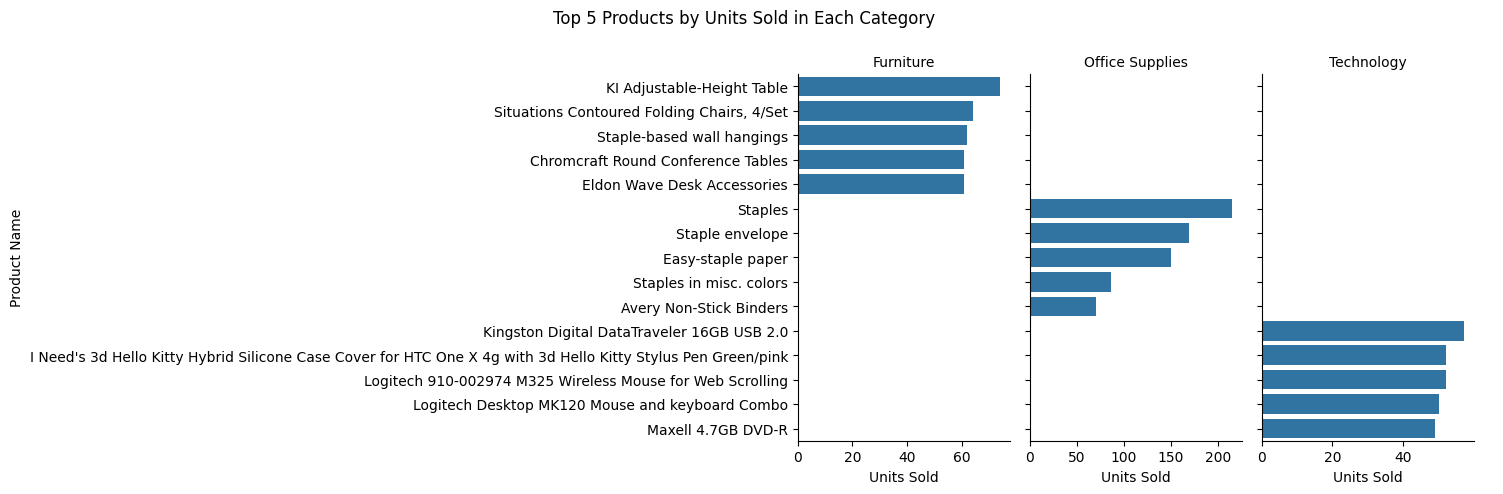

In [22]:
#top 5 products within each category
cat_product_units = (
    df.groupby(["category", "product_name"])["quantity"]
      .sum()
      .reset_index(name="total_units_sold")
)

top_5_by_category = (
    cat_product_units
      .sort_values(["category", "total_units_sold"], ascending=[True, False])
      .groupby("category")
      .head(5)
)

g = sns.catplot(
    data=top_5_by_category,
    x="total_units_sold",
    y="product_name",
    col="category",
    kind="bar",
    sharex=False,
    height=5,
    aspect=1
)

g.set_titles("{col_name}")
g.set_axis_labels("Units Sold", "Product Name")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Top 5 Products by Units Sold in Each Category")
plt.show()

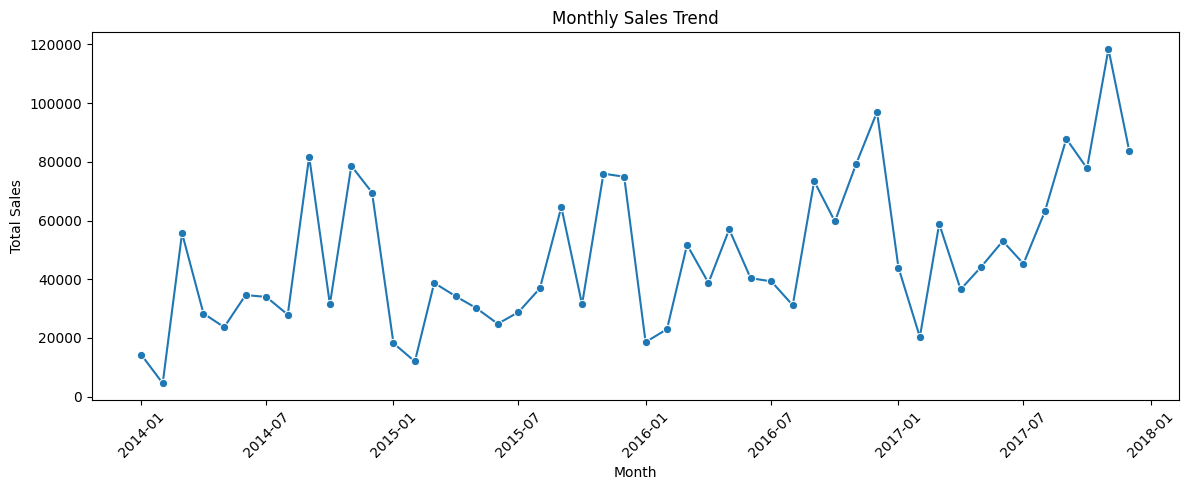

In [23]:
# Monthly Sales Trend
df["year_month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()

monthly_sales = (
    df.groupby("year_month")["sales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="year_month", y="sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

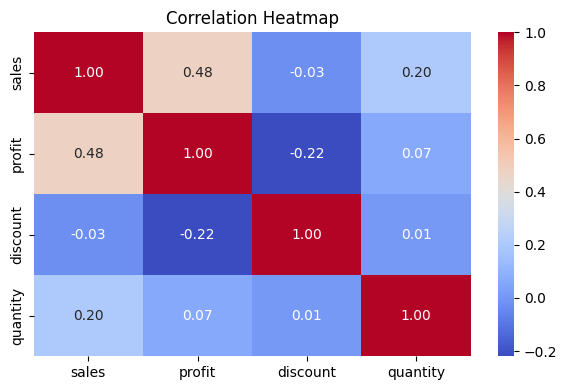

In [24]:
num_cols = ["sales", "profit", "discount", "quantity"]
corr = df[num_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Advanced Analytics: RFM + K‑Means

In this section we:

1. Build an RFM table at the customer level:
   - **Recency** – how many days since the customer’s last purchase.
   - **Frequency** – how many distinct orders the customer has placed.
   - **Monetary** – total sales amount for the customer.

2. Standardize the RFM features and apply **K-Means clustering (k = 4)** to segment customers.

3. Summarize the characteristics of each cluster (average Recency, Frequency, Monetary).

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans




# Reference date: one day after the last order date in the dataset
ref_date = df["order_date"].max() + pd.Timedelta(days=1)
print("Reference date for recency:", ref_date.date())

# Build RFM at customer level
rfm = (
    df.groupby("customer_id")
      .agg(
          last_order_date=("order_date", "max"),
          frequency=("order_id", "nunique"),
          monetary=("sales", "sum")
      )
      .reset_index()
)

# Calculate Recency in days
rfm["recency"] = (ref_date - rfm["last_order_date"]).dt.days

# Keep only Recency, Frequency, Monetary + ID
rfm = rfm[["customer_id", "recency", "frequency", "monetary"]]

rfm.head()

Reference date for recency: 2017-12-31


,customer_id,recency,frequency,monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156


In [26]:
# Features to use for clustering
features = ["recency", "frequency", "monetary"]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])

# Put back in a DataFrame (optional, just for inspection)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=[f + "_scaled" for f in features])
rfm_scaled_df.head()

,recency_scaled,frequency_scaled,monetary_scaled
0,0.199889,-0.516429,1.015112
1,-0.686762,1.052644,-0.700590
2,0.602912,-0.908697,-0.421139
3,-0.493311,-0.124161,0.833680
4,1.441199,-1.300965,-0.765391


In [27]:
# Set number of clusters
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(rfm_scaled)

# Attach cluster labels back to RFM table
rfm["cluster"] = cluster_labels

# Inspect basic cluster stats
cluster_summary = (
    rfm.groupby("cluster")[["recency", "frequency", "monetary"]]
       .mean()
       .round(2)
       .reset_index()
)

cluster_sizes = rfm["cluster"].value_counts().rename("n_customers").reset_index()
cluster_sizes.columns = ["cluster", "n_customers"]

cluster_summary = cluster_summary.merge(cluster_sizes, on="cluster")

cluster_summary

,cluster,recency,frequency,monetary,n_customers
0,0,72.74,8.52,3322.22,298
1,1,101.20,4.73,1669.69,335
2,2,123.72,8.30,9479.55,64
3,3,559.49,3.70,1470.23,96


# Advanced Analytics

###
Advanced Analytics: RFM + K‑Means

In this section we:

1. Build an RFM table at the customer level:
   - **Recency** – how many days since the customer’s last purchase.
   - **Frequency** – how many distinct orders the customer has placed.
   - **Monetary** – total sales amount for the customer.

2. Standardize the RFM features and apply **K-Means clustering (k = 4)** to segment customers.

3. Summarize the characteristics of each cluster (average Recency, Frequency, Monetary).

In [28]:
# Reference date: one day after the last order date in the dataset
ref_date = df["order_date"].max() + pd.Timedelta(days=1)
print("Reference date for recency:", ref_date.date())

# Build RFM at customer level
rfm = (
    df.groupby("customer_id")
      .agg(
          last_order_date=("order_date", "max"),
          frequency=("order_id", "nunique"),
          monetary=("sales", "sum")
      )
      .reset_index()
)

# Calculate Recency in days
rfm["recency"] = (ref_date - rfm["last_order_date"]).dt.days

# Keep only Recency, Frequency, Monetary + ID
rfm = rfm[["customer_id", "recency", "frequency", "monetary"]]

rfm.head()

Reference date for recency: 2017-12-31


,customer_id,recency,frequency,monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156


In [29]:
# Features to use for clustering
features = ["recency", "frequency", "monetary"]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])

# Put back in a DataFrame (optional, just for inspection)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=[f + "_scaled" for f in features])
rfm_scaled_df.head()

,recency_scaled,frequency_scaled,monetary_scaled
0,0.199889,-0.516429,1.015112
1,-0.686762,1.052644,-0.700590
2,0.602912,-0.908697,-0.421139
3,-0.493311,-0.124161,0.833680
4,1.441199,-1.300965,-0.765391


In [30]:
# Set number of clusters
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(rfm_scaled)

# Attach cluster labels back to RFM table
rfm["cluster"] = cluster_labels

# Inspect basic cluster stats
cluster_summary = (
    rfm.groupby("cluster")[["recency", "frequency", "monetary"]]
       .mean()
       .round(2)
       .reset_index()
)

cluster_sizes = rfm["cluster"].value_counts().rename("n_customers").reset_index()
cluster_sizes.columns = ["cluster", "n_customers"]

cluster_summary = cluster_summary.merge(cluster_sizes, on="cluster")

cluster_summary

,cluster,recency,frequency,monetary,n_customers
0,0,72.74,8.52,3322.22,298
1,1,101.20,4.73,1669.69,335
2,2,123.72,8.30,9479.55,64
3,3,559.49,3.70,1470.23,96


In [31]:
# How many customers in each cluster
print("Customers per cluster:")
print(cluster_sizes.sort_values("cluster"))

# Optional: quick look at sample customers from each cluster
for c in sorted(rfm["cluster"].unique()):
    print(f"\nSample customers from cluster {c}:")
    display(rfm[rfm["cluster"] == c].head(3))

Customers per cluster:
   cluster  n_customers
1        0          298
0        1          335
3        2           64
2        3           96

Sample customers from cluster 0:


,customer_id,recency,frequency,monetary,cluster
1,AA-10375,20,9,1056.390,0
3,AA-10645,56,6,5086.935,0
8,AB-10165,26,8,1113.838,0



Sample customers from cluster 1:


,customer_id,recency,frequency,monetary,cluster
0,AA-10315,185,5,5563.560,1
2,AA-10480,260,4,1790.512,1
7,AB-10150,42,5,966.710,1



Sample customers from cluster 2:


,customer_id,recency,frequency,monetary,cluster
5,AB-10060,55,8,7755.620,2
6,AB-10105,42,10,14473.571,2
34,AH-10690,411,12,7888.294,2



Sample customers from cluster 3:


,customer_id,recency,frequency,monetary,cluster
4,AB-10015,416,3,886.156,3
17,AF-10885,416,4,861.565,3
23,AG-10525,846,4,1455.038,3


Cluster 0 contains fairly recent, moderately frequent customers with medium spending, making them solid “active” customers.

Cluster 1 includes older, less recent customers with mid‑level frequency but relatively high monetary value, suggesting previously valuable customers who may be slipping away.

Cluster 2 holds very high‑value, high‑frequency customers with large total spend, representing your top “VIP” or “champion” segment.

Cluster 3 consists of very old, low‑spending, low‑frequency customers, indicating a “lapsed” or low‑value group with limited current contribution.

###  Monthly Sales Forecasting with ARIMA

Goal: Use historical Superstore sales to forecast total monthly sales for the next 6 months.

Steps:
1. Aggregate daily order data to monthly total sales.
2. Visualize the monthly sales series.
3. Fit an ARIMA model to the monthly sales.
4. Forecast the next 6 months and visualize actual vs forecast.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

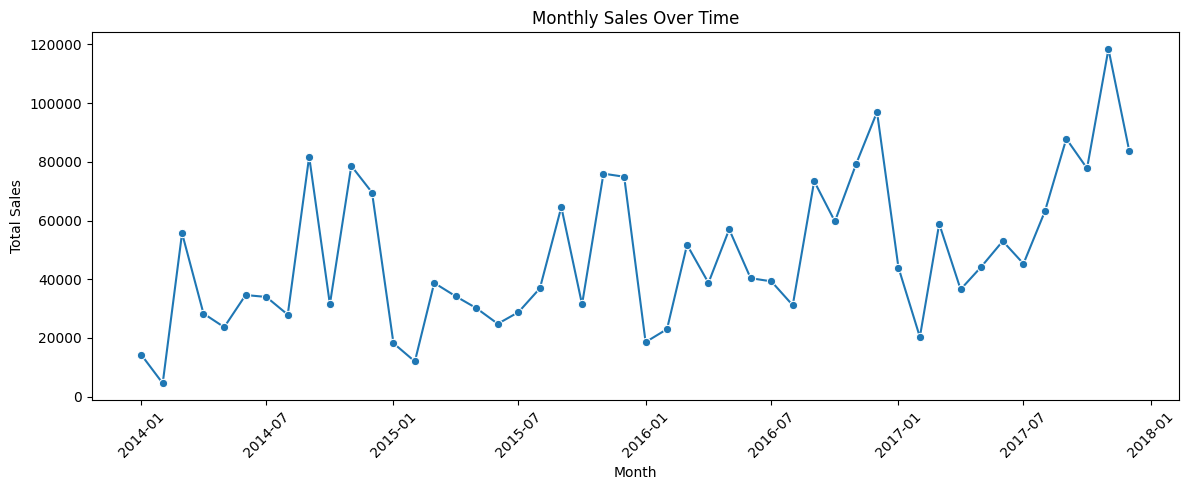

In [33]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="year_month", y="sales", marker="o")
plt.title("Monthly Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# Set index to datetime for time series modelling
ts = monthly_sales.set_index("year_month")["sales"]

# Simple ARIMA model (p, d, q) = (1, 1, 1)
# You can tune these later
model = sm.tsa.ARIMA(ts, order=(1, 1, 1))
results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   48
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -539.895
Date:                Fri, 05 Jun 2026   AIC                           1085.789
Time:                        08:19:40   BIC                           1091.340
Sample:                    01-01-2014   HQIC                          1087.878
                         - 12-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2278      0.262      0.868      0.386      -0.287       0.742
ma.L1         -0.8396      0.140     -5.979      0.000      -1.115      -0.564
sigma2      5.976e+08   6.93e-11   8.63e+18      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [35]:
# Forecast next 6 months
n_forecast = 6
forecast_res = results.get_forecast(steps=n_forecast)

forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

forecast_df = forecast_mean.to_frame(name="forecast_sales")
forecast_df["lower_ci"] = forecast_ci.iloc[:, 0]
forecast_df["upper_ci"] = forecast_ci.iloc[:, 1]

forecast_df

,forecast_sales,lower_ci,upper_ci
2018-01-01,75259.028220,27346.318805,123171.737635
2018-02-01,73306.800169,21910.254132,124703.346206
2018-03-01,72862.101786,20100.629973,125623.573599
2018-04-01,72760.803860,18983.633976,126537.973745
2018-05-01,72737.729188,18028.433435,127447.024940
2018-06-01,72732.473004,17120.881898,128344.064109


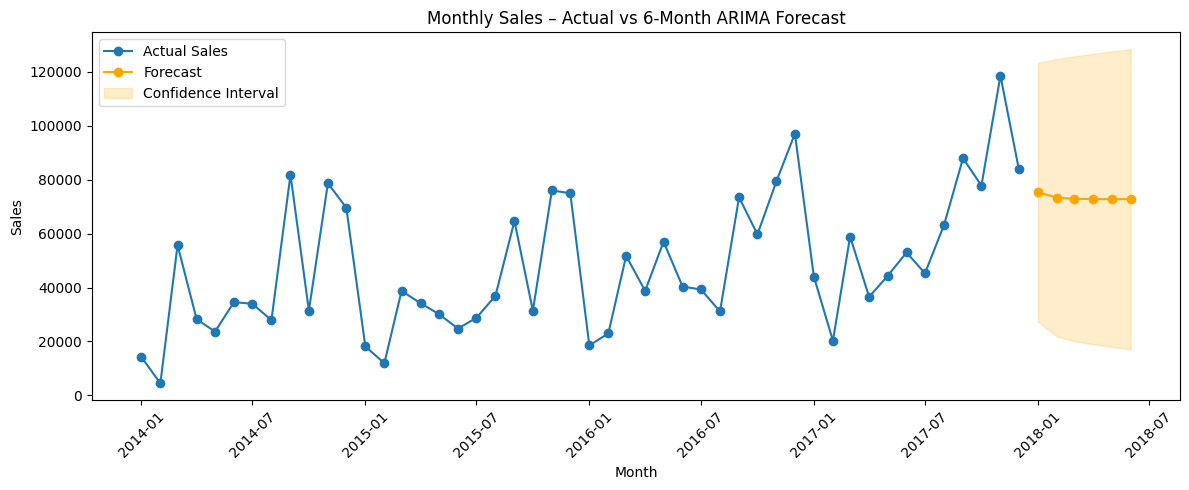

In [36]:
plt.figure(figsize=(12, 5))

# Plot historical sales
plt.plot(ts.index, ts.values, label="Actual Sales", marker="o")

# Plot forecast
plt.plot(forecast_df.index, forecast_df["forecast_sales"], label="Forecast", marker="o", color="orange")

# Confidence interval as shaded area
plt.fill_between(
    forecast_df.index,
    forecast_df["lower_ci"],
    forecast_df["upper_ci"],
    color="orange",
    alpha=0.2,
    label="Confidence Interval"
)

plt.title("Monthly Sales – Actual vs 6-Month ARIMA Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 🔬 Advanced Analytics: RFM Segmentation + K-Means Clustering

### Overview
This section applies **RFM (Recency, Frequency, Monetary)** analysis combined with **K-Means Clustering (k=4)** to segment Superstore customers into distinct behavioral groups — enabling data-driven marketing, retention, and revenue strategies.

---

### Methodology

**Step 1 – Build the RFM Table**
Each customer is profiled across three dimensions:
- **Recency** – Days since their most recent purchase (lower = more active)
- **Frequency** – Total number of distinct orders placed
- **Monetary** – Cumulative sales revenue generated

The reference date is set to one day after the last order in the dataset (`2017-12-31`), ensuring recency is computed accurately.

**Step 2 – Feature Standardization & Clustering**
RFM features are standardized (z-score normalization) before applying **K-Means clustering with k=4**, preventing any single feature from dominating due to scale differences. The model assigns each customer to one of four clusters.

**Step 3 – Cluster Profiling**
Average RFM values are computed per cluster to identify and label each segment's behavior.

---

### Cluster Results & Interpretation

| Cluster | Avg. Recency (days) | Avg. Frequency (orders) | Avg. Monetary ($) | # Customers | Segment Label |
|---------|---------------------|--------------------------|-------------------|-------------|---------------|
| 0 | 72.74 | 8.52 | $3,322.22 | 298 | ✅ Active Customers |
| 1 | 101.20 | 4.73 | $1,669.69 | 335 | ⚠️ Slipping Away |
| 2 | 123.72 | 8.30 | $9,479.55 | 64 | 🏆 VIP / Champions |
| 3 | 559.49 | 3.70 | $1,470.23 | 96 | ❌ Lapsed / Low-Value |

**Cluster 0 – Active Customers (298 customers)**
These customers purchased fairly recently (~73 days ago), order moderately often (~8–9 times), and spend a respectable $3,322 on average. They represent a healthy, engaged base that should be nurtured with loyalty rewards and upsell campaigns.

**Cluster 1 – Slipping Away (335 customers)**
The largest segment, with customers who haven't purchased in ~101 days and have lower order frequency. Despite some historical spending ($1,670), engagement is declining. This group is a prime target for **win-back campaigns** and personalized re-engagement offers.

**Cluster 2 – VIP / Champions (64 customers)**
Although only 64 customers, this group drives outsized revenue at an average of **$9,480 per customer** — nearly 3x the Active cluster. Frequency is high (~8.3 orders). These are the store's most valuable customers and deserve **premium treatment, early access, and exclusive benefits**.

**Cluster 3 – Lapsed / Low-Value (96 customers)**
These customers last purchased ~560 days ago (~1.5 years), rarely order, and spend the least. Without meaningful re-engagement signals, resources should not be heavily invested here. They may be appropriate for **low-cost, automated reactivation emails** only.

---

### Key Takeaways
- **Unsupervised ML (K-Means)** successfully identified four distinct, actionable customer personas from raw transactional data.
- The **VIP cluster**, though smallest in size, represents the highest revenue opportunity — protecting this segment is critical.
- **RFM + Clustering** is a powerful, interpretable technique that bridges data science and business strategy without requiring labeled training data.
- This analysis can directly inform **targeted marketing spend allocation**, customer lifetime value (CLV) modeling, and churn prediction pipelines.

---

> **Tech Stack:** Python · Pandas · Scikit-learn (KMeans, StandardScaler) · Google Colab
> **Dataset:** Sample Superstore (Retail Transactions)